In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot settings
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [30]:
df = pd.read_csv('beverage_cleaned.csv')

print("Data loaded successfully!")
print("Shape:", df.shape)
df.head()

Data loaded successfully!
Shape: (29998, 16)


,id,sale_year,sale_month,supplier,item_code,item_desc,item_type,retail_sales,retail_transfers,warehouse_sales,month_name,total_units,dominant_channel,item_type_clean,is_return,is_dead_stock
0,1,2020,1,REPUBLIC NATIONAL DISTRIBUTING CO,100009,BOOTLEG RED - 750ML,WINE,0.00,0.0,2.0,January,2.00,Warehouse,WINE,0,1
1,2,2020,1,PWSWN INC,100024,MOMENT DE PLAISIR - 750ML,WINE,0.00,1.0,4.0,January,5.00,Warehouse,WINE,0,1
2,3,2020,1,RELIABLE CHURCHILL LLLP,1001,S SMITH ORGANIC PEAR CIDER - 18.7OZ,BEER,0.00,0.0,1.0,January,1.00,Warehouse,BEER,0,1
3,4,2020,1,LANTERNA DISTRIBUTORS INC,100145,SCHLINK HAUS KABINETT - 750ML,WINE,0.00,0.0,1.0,January,1.00,Warehouse,WINE,0,1
4,5,2020,1,DIONYSOS IMPORTS INC,100293,SANTORINI GAVALA WHITE - 750ML,WINE,0.82,0.0,0.0,January,0.82,Retail,WINE,0,0


In [31]:
print("Column Names:")
print(df.columns.tolist())

# Rename columns to make them consistent
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print("\nCleaned Column Names:")
print(df.columns.tolist())

Column Names:
['id', 'sale_year', 'sale_month', 'supplier', 'item_code', 'item_desc', 'item_type', 'retail_sales', 'retail_transfers', 'warehouse_sales', 'month_name', 'total_units', 'dominant_channel', 'item_type_clean', 'is_return', 'is_dead_stock']

Cleaned Column Names:
['id', 'sale_year', 'sale_month', 'supplier', 'item_code', 'item_desc', 'item_type', 'retail_sales', 'retail_transfers', 'warehouse_sales', 'month_name', 'total_units', 'dominant_channel', 'item_type_clean', 'is_return', 'is_dead_stock']


In [32]:
print("DATASET OVERVIEW :- ")
print(f"Total Records : {len(df):,}")
print(f"Total Columns : {df.shape[1]}")
print(f"Unique Suppliers : {df['supplier'].nunique():,}")
print(f"Unique SKUs : {df['item_code'].nunique():,}")
print(f"Unique Item Types : {df['item_type'].nunique()}")
print(f"Months Available : {sorted(df['sale_month'].unique())}")
print()
print("Column Data Types:")
print(df.dtypes)
print()
print("Missing Values:")
print(df.isnull().sum())

DATASET OVERVIEW :- 
Total Records : 29,998
Total Columns : 16
Unique Suppliers : 290
Unique SKUs : 15,666
Unique Item Types : 8
Months Available : [np.int64(1), np.int64(3), np.int64(7), np.int64(9)]

Column Data Types:
id                    int64
sale_year             int64
sale_month            int64
supplier             object
item_code            object
item_desc            object
item_type            object
retail_sales        float64
retail_transfers    float64
warehouse_sales     float64
month_name           object
total_units         float64
dominant_channel     object
item_type_clean      object
is_return             int64
is_dead_stock         int64
dtype: object

Missing Values:
id                   0
sale_year            0
sale_month           0
supplier            32
item_code            0
item_desc            0
item_type            0
retail_sales         0
retail_transfers     0
warehouse_sales      0
month_name           0
total_units          0
dominant_channel     0
i

In [33]:
print("SUMMARY STATISTICS — UNIT VOLUMES :- ")

summary = df[['retail_sales', 'warehouse_sales',
              'retail_transfers', 'total_units']].describe()
print(summary.round(2))

SUMMARY STATISTICS — UNIT VOLUMES :- 
       retail_sales  warehouse_sales  retail_transfers  total_units
count      29998.00         29998.00          29998.00     29998.00
mean           6.94            27.43              6.59        40.97
std           33.08           272.18             27.88       307.51
min           -0.42         -3999.00             -6.00     -3999.00
25%            0.00             0.00              0.00         1.00
50%            0.16             1.00              0.00         3.00
75%            2.92             6.00              3.00        15.00
max         2739.00         18317.00           1507.00     20532.00


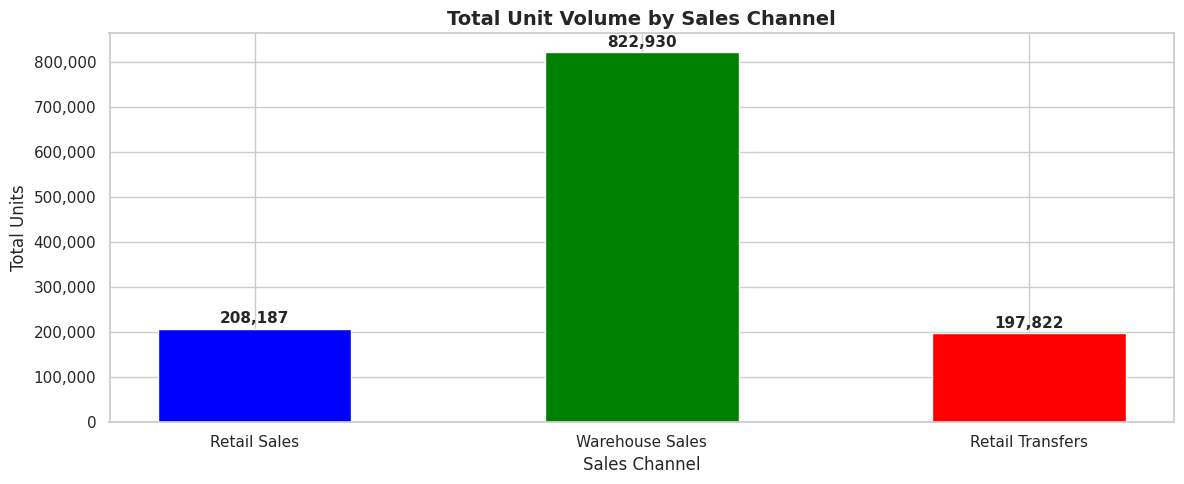

In [34]:
# UC1: Total Unit Volume by Sales Channel (Bar Chart)
# Insight: Warehouse dominates total unit volume

channel_totals = pd.DataFrame({
    'Channel': ['Retail Sales', 'Warehouse Sales', 'Retail Transfers'],
    'Total Units': [
        df['retail_sales'].sum(),
        df['warehouse_sales'].sum(),
        df['retail_transfers'].sum()
    ]
})

fig, ax = plt.subplots()
bars = ax.bar(
    channel_totals['Channel'],
    channel_totals['Total Units'],
    color=['Blue', 'Green', 'Red'],
    edgecolor='white',
    width=0.5
)

# Add value labels on top of bars
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5000,
        f"{bar.get_height():,.0f}",
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

ax.set_title('Total Unit Volume by Sales Channel', fontsize=14, fontweight='bold')
ax.set_xlabel('Sales Channel')
ax.set_ylabel('Total Units')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('uc1_channel_volume.png', dpi=150)
plt.show()

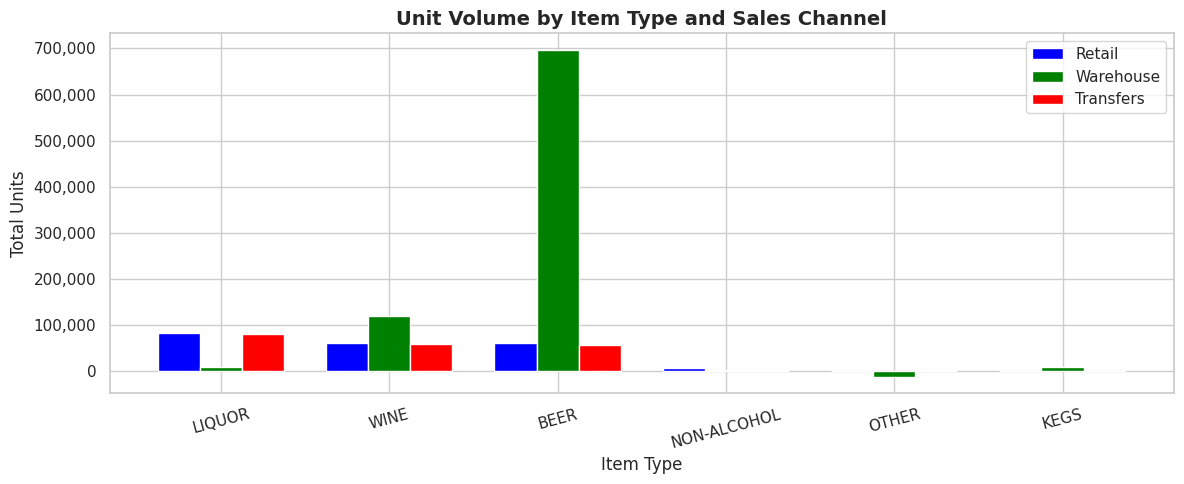

In [35]:
# UC1: Channel Volume by Item Type (Grouped Bar Chart)
# Insight: Beer moves via warehouse, Liquor leads retail

channel_by_type = df.groupby('item_type_clean').agg(
    Retail=('retail_sales', 'sum'),
    Warehouse=('warehouse_sales', 'sum'),
    Transfers=('retail_transfers', 'sum')
).reset_index().sort_values('Retail', ascending=False)

x = np.arange(len(channel_by_type))
width = 0.25

fig, ax = plt.subplots()
ax.bar(x - width, channel_by_type['Retail'],    width, label='Retail', color='Blue')
ax.bar(x,         channel_by_type['Warehouse'], width, label='Warehouse', color='Green')
ax.bar(x + width, channel_by_type['Transfers'], width, label='Transfers', color='Red')

ax.set_title('Unit Volume by Item Type and Sales Channel', fontsize=14, fontweight='bold')
ax.set_xlabel('Item Type')
ax.set_ylabel('Total Units')
ax.set_xticks(x)
ax.set_xticklabels(channel_by_type['item_type_clean'], rotation=15)
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('uc1_channel_by_type.png', dpi=150)
plt.show()

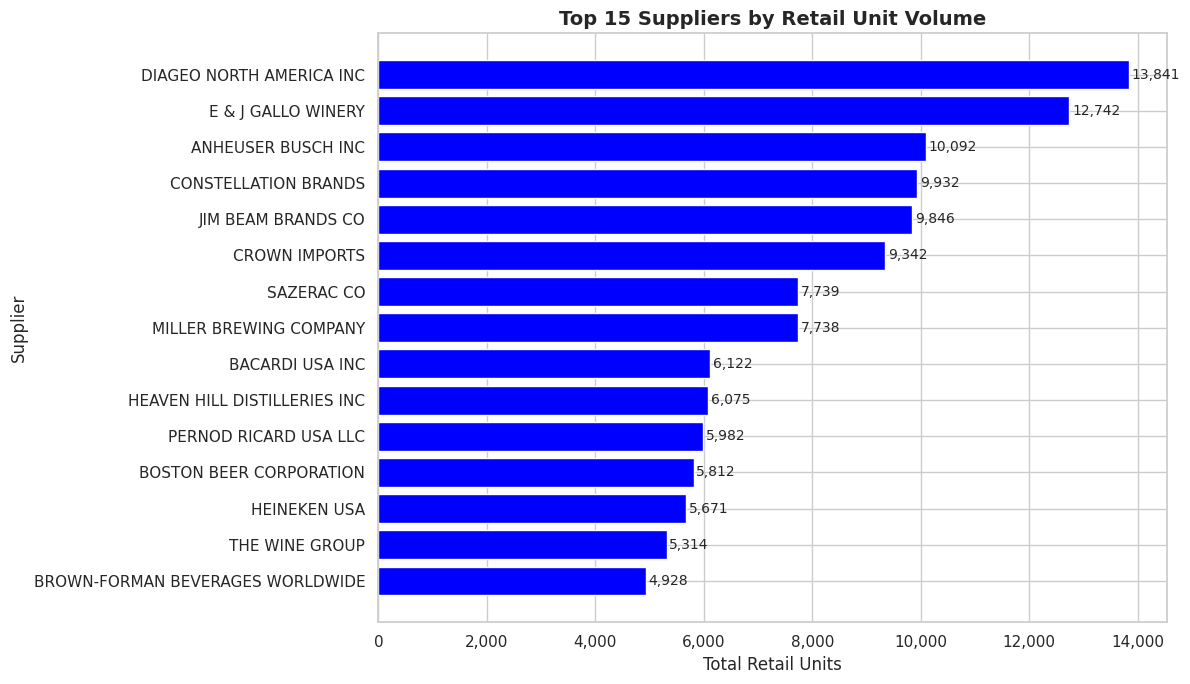

In [36]:
# UC2: Top 15 Suppliers by Retail Units (Horizontal Bar)
# Insight: Diageo and E&J Gallo lead retail unit volume

top_suppliers = df.groupby('supplier')['retail_sales'].sum() \
                  .reset_index() \
                  .sort_values('retail_sales', ascending=False) \
                  .head(15)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(
    top_suppliers['supplier'],
    top_suppliers['retail_sales'],
    color='Blue',
    edgecolor='white'
)

for bar in bars:
    ax.text(
        bar.get_width() + 50,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():,.0f}",
        va='center', fontsize=10
    )

ax.set_title('Top 15 Suppliers by Retail Unit Volume', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Retail Units')
ax.set_ylabel('Supplier')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('uc2_top_suppliers.png', dpi=150)
plt.show()

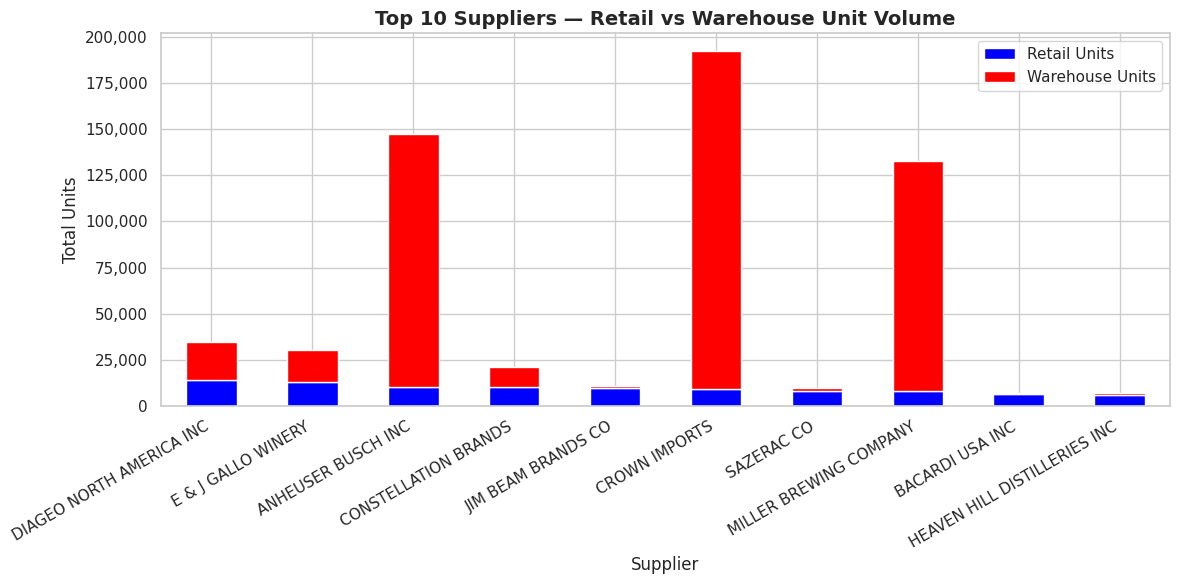

Chart saved!


In [37]:
# UC2: Top 10 Suppliers — Retail vs Warehouse Split
# Insight: Identify retail-dominant vs warehouse-dominant suppliers

top10_names = df.groupby('supplier')['retail_sales'].sum() \
                .nlargest(10).index

sup_channel = df[df['supplier'].isin(top10_names)] \
                .groupby('supplier')[['retail_sales', 'warehouse_sales']] \
                .sum().sort_values('retail_sales', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
sup_channel.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=['Blue', 'Red'],
    edgecolor='white'
)

ax.set_title('Top 10 Suppliers — Retail vs Warehouse Unit Volume',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Supplier')
ax.set_ylabel('Total Units')
ax.legend(['Retail Units', 'Warehouse Units'])
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('uc2_supplier_channel_split.png', dpi=150)
plt.show()
print("Chart saved!")

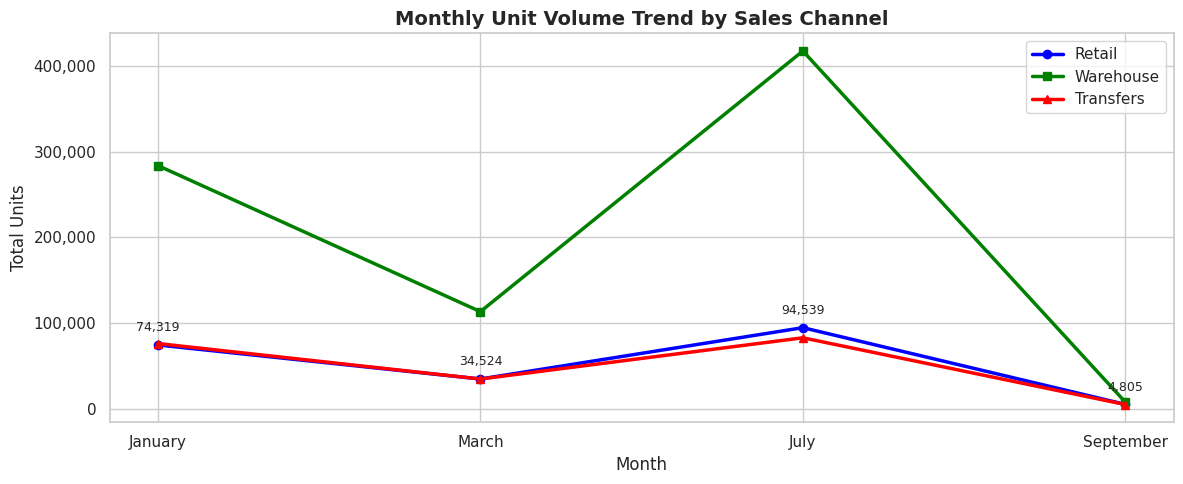

In [38]:
# UC3: Monthly Sales Trend
# Insight: July is the peak month across all channels

monthly = df.groupby(['sale_month', 'month_name']).agg(
    Retail=('retail_sales', 'sum'),
    Warehouse=('warehouse_sales', 'sum'),
    Transfers=('retail_transfers', 'sum')
).reset_index().sort_values('sale_month')

fig, ax = plt.subplots()
ax.plot(monthly['month_name'], monthly['Retail'],
        marker='o', linewidth=2.5, color='Blue', label='Retail')
ax.plot(monthly['month_name'], monthly['Warehouse'],
        marker='s', linewidth=2.5, color='Green', label='Warehouse')
ax.plot(monthly['month_name'], monthly['Transfers'],
        marker='^', linewidth=2.5, color='Red', label='Transfers')

# Annotate retail values on the line
for _, row in monthly.iterrows():
    ax.annotate(
        f"{row['Retail']:,.0f}",
        (row['month_name'], row['Retail']),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center', fontsize=9
    )

ax.set_title('Monthly Unit Volume Trend by Sales Channel',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Units')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('uc3_monthly_trend.png', dpi=150)
plt.show()

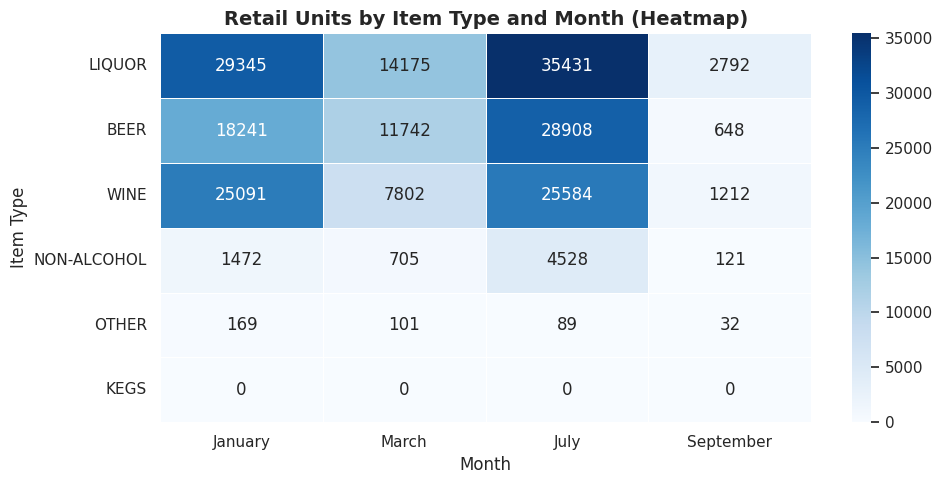

Chart saved!


In [39]:
# UC3: Seasonal Breakdown by Item Type
# Insight: Which category spikes the most in July?

seasonal = df.groupby(['item_type_clean', 'month_name'])['retail_sales'] \
             .sum().unstack(fill_value=0)

# Reorder months chronologically
month_order = ['January', 'March', 'July', 'September']
seasonal = seasonal[[m for m in month_order if m in seasonal.columns]]
seasonal = seasonal.sort_values('July', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(
    seasonal,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Retail Units by Item Type and Month (Heatmap)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Item Type')
plt.tight_layout()
plt.savefig('uc3_seasonal_heatmap.png', dpi=150)
plt.show()
print("Chart saved!")

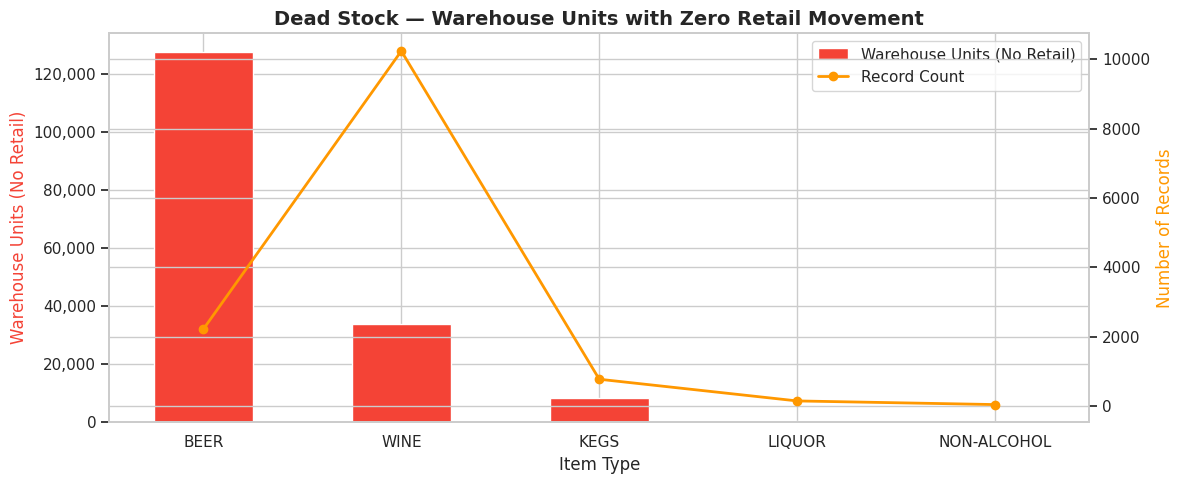

In [40]:
# UC4: Dead Stock Analysis by Item Type
# Insight: Items sitting in warehouse with zero retail movement

dead_stock = df[df['is_dead_stock'] == 1] \
               .groupby('item_type_clean')['warehouse_sales'] \
               .agg(['sum', 'count']) \
               .reset_index() \
               .rename(columns={'sum': 'warehouse_units', 'count': 'record_count'}) \
               .sort_values('warehouse_units', ascending=False)

fig, ax1 = plt.subplots()
bars = ax1.bar(
    dead_stock['item_type_clean'],
    dead_stock['warehouse_units'],
    color='#F44336',
    edgecolor='white',
    width=0.5,
    label='Warehouse Units (No Retail)'
)

ax2 = ax1.twinx()
ax2.plot(
    dead_stock['item_type_clean'],
    dead_stock['record_count'],
    color='#FF9800',
    marker='o',
    linewidth=2,
    label='Record Count'
)

ax1.set_title('Dead Stock — Warehouse Units with Zero Retail Movement',
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Item Type')
ax1.set_ylabel('Warehouse Units (No Retail)', color='#F44336')
ax2.set_ylabel('Number of Records', color='#FF9800')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.savefig('uc4_dead_stock.png', dpi=150)
plt.show()

In [41]:
# UC4: Returns Summary Printout

returns = df[df['is_return'] == 1]

print("RETURNS & NEGATIVE ADJUSTMENT SUMMARY :- ")
print(f"Total return records     : {len(returns)}")
print(f"Negative retail units    : {returns['retail_sales'].sum():.2f}")
print(f"Negative warehouse units : {returns['warehouse_sales'].sum():.2f}")
print()
print("Returns breakdown by Item Type:")
print(returns.groupby('item_type_clean')[['retail_sales', 'warehouse_sales']]
      .sum().round(2))

RETURNS & NEGATIVE ADJUSTMENT SUMMARY :- 
Total return records     : 82
Negative retail units    : 4.43
Negative warehouse units : -13510.73

Returns breakdown by Item Type:
                 retail_sales  warehouse_sales
item_type_clean                               
BEER                     0.58            -8.33
KEGS                     0.00           -44.00
LIQUOR                  -0.34             0.00
OTHER                   -0.08        -13444.00
WINE                     4.27           -14.40


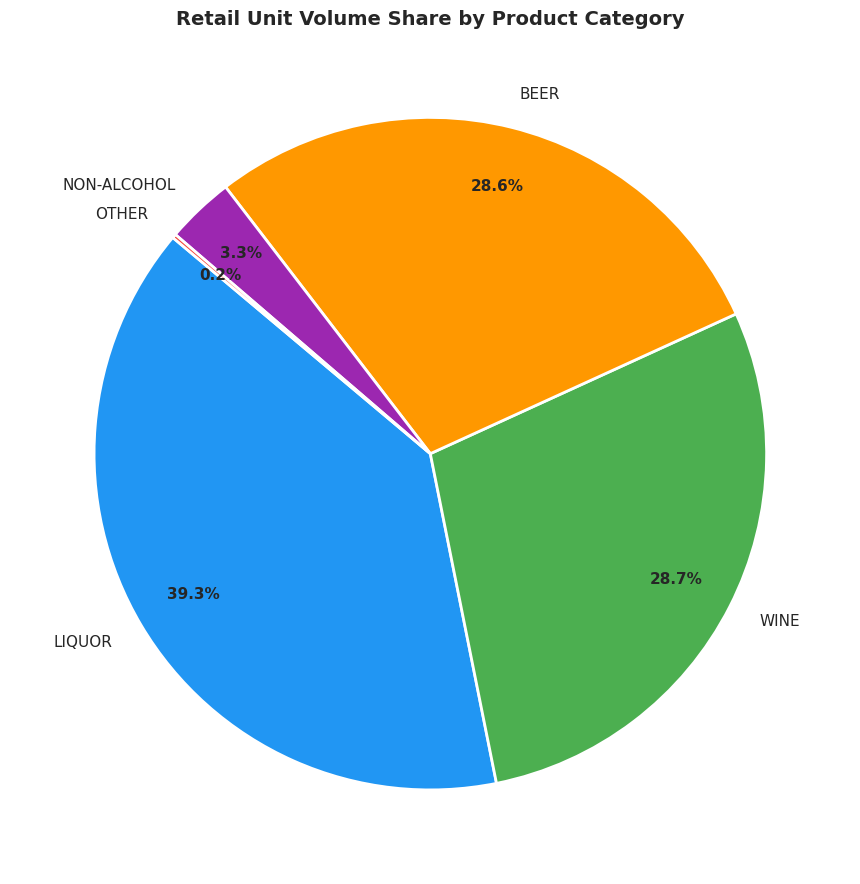

In [42]:
# UC5: Product Category Mix
# Insight: Liquor leads retail share, Wine second

category_retail = df.groupby('item_type_clean')['retail_sales'] \
                    .sum().sort_values(ascending=False)

# Keep only categories with actual retail units
category_retail = category_retail[category_retail > 0]

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    category_retail,
    labels=category_retail.index,
    autopct='%1.1f%%',
    colors=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336'],
    startangle=140,
    pctdistance=0.82,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

for text in autotexts:
    text.set_fontsize(11)
    text.set_fontweight('bold')

ax.set_title('Retail Unit Volume Share by Product Category',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('uc5_category_mix_pie.png', dpi=150)
plt.show()

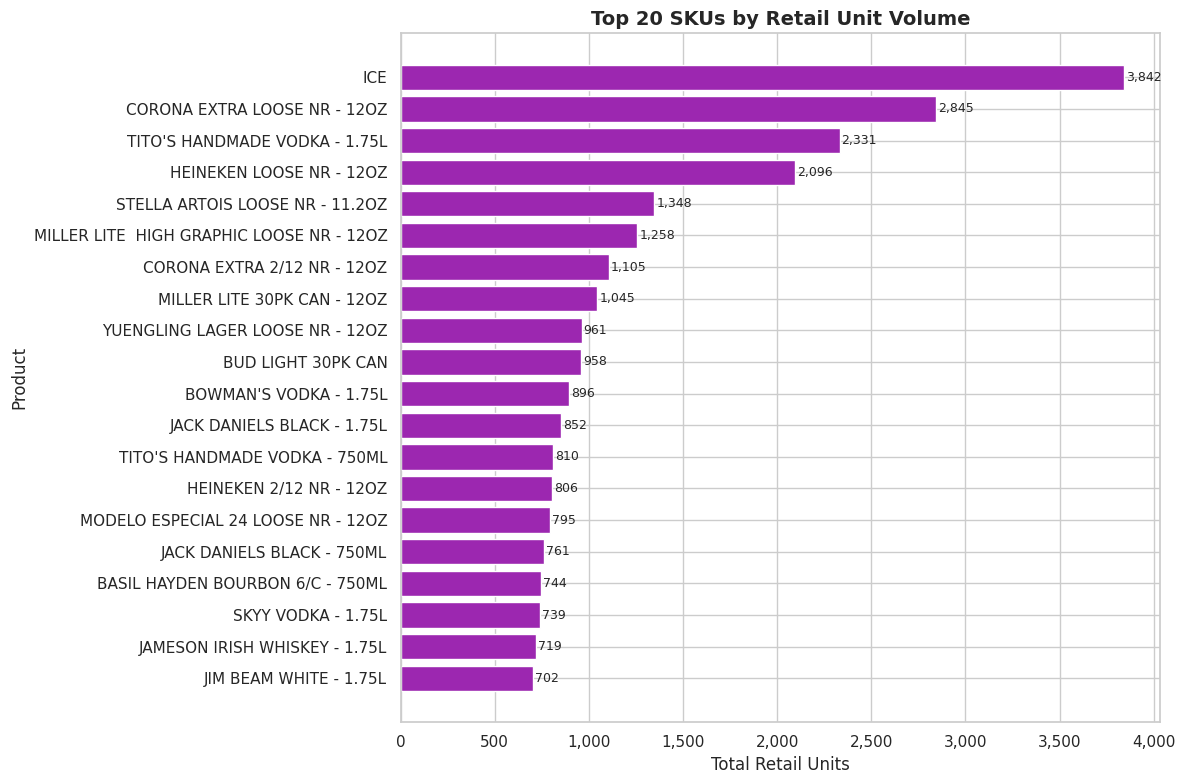

In [43]:
# UC5: Top 20 SKUs by Retail Units
# Insight: Best selling individual products across all months

top_skus = df[df['retail_sales'] > 0] \
             .groupby(['item_code', 'item_desc', 'item_type_clean'])['retail_sales'] \
             .sum().reset_index() \
             .sort_values('retail_sales', ascending=False) \
             .head(20)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.barh(
    top_skus['item_desc'],
    top_skus['retail_sales'],
    color='#9C27B0',
    edgecolor='white'
)

for bar in bars:
    ax.text(
        bar.get_width() + 10,
        bar.get_y() + bar.get_height() / 2,
        f"{bar.get_width():,.0f}",
        va='center', fontsize=9
    )

ax.set_title('Top 20 SKUs by Retail Unit Volume', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Retail Units')
ax.set_ylabel('Product')
ax.invert_yaxis()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.savefig('uc5_top_skus.png', dpi=150)
plt.show()

Correlation Matrix:
                  retail_sales  warehouse_sales  retail_transfers  total_units
retail_sales              1.00             0.49              0.84         0.62
warehouse_sales           0.49             1.00              0.54         0.99
retail_transfers          0.84             0.54              1.00         0.66
total_units               0.62             0.99              0.66         1.00


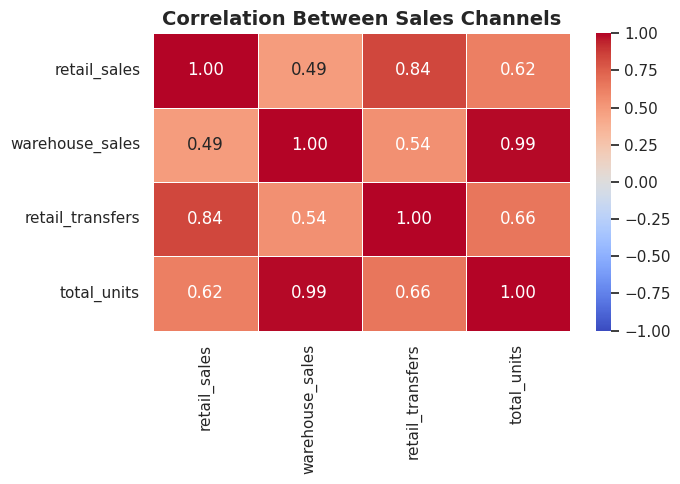

In [44]:
# Correlation Analysis Between Channels
# Insight: How strongly do the three channels move together?

corr = df[['retail_sales', 'warehouse_sales',
           'retail_transfers', 'total_units']].corr().round(2)

print("Correlation Matrix:")
print(corr)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    ax=ax,
    vmin=-1, vmax=1
)
ax.set_title('Correlation Between Sales Channels',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()